# Data Preprocessing for Sentiment Analysis

This notebook prepares the customer service conversation dataset for training an attention-based model.

**Steps:**
1. Load & inspect data
2. Feature selection
3. Text cleaning
4. Label encoding
5. Train/validation split (no test leakage)
6. Tokenization
7. Save preprocessed data

In [1]:
import pandas as pd
import numpy as np
import re
import os

train_df = pd.read_csv('../dataset/train.csv')
test_df = pd.read_csv('../dataset/test.csv')

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
train_df.head(3)

Train: (970, 11), Test: (30, 11)


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...


## 1. Feature Selection

From the EDA, we observed:
- `conversation` is the primary text feature for the transformer
- `issue_category` has the strongest correlation with sentiment (Cramér's V = 0.739)
- `issue_area` also correlates well (V = 0.295)
- `issue_category_sub_category` is redundant (combines issue_category + issue_sub_category)
- `agent_experience_level_desc` is redundant (describes agent_experience_level)

**Decision:** Use `conversation` as the main input. Drop redundant columns.

In [2]:
# Drop redundant features
drop_cols = ['issue_category_sub_category', 'agent_experience_level_desc']

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print(f"Remaining columns: {list(train_df.columns)}")

Remaining columns: ['issue_area', 'issue_category', 'issue_sub_category', 'customer_sentiment', 'product_category', 'product_sub_category', 'issue_complexity', 'agent_experience_level', 'conversation']


## 2. Text Cleaning

The `conversation` column contains agent-customer dialogues. We apply minimal cleaning to preserve semantic meaning for the transformer:
- Normalize whitespace (collapse multiple spaces/newlines)
- Keep speaker labels (`Agent:`, `Customer:`) as they provide useful context
- Remove any leading/trailing whitespace

**Justification:** Transformer tokenizers (e.g., BERT) handle punctuation, casing, and special characters well, so aggressive cleaning (lowercasing, removing punctuation) would remove useful signal.

In [3]:
def clean_conversation(text):
    """Minimal text cleaning for transformer input."""
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['conversation'] = train_df['conversation'].apply(clean_conversation)
test_df['conversation'] = test_df['conversation'].apply(clean_conversation)

# Verify
print(f"Sample cleaned text (first 200 chars):")
print(train_df['conversation'].iloc[0][:200])

Sample cleaned text (first 200 chars):
Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today? Customer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG), but I'


## 3. Label Encoding

Encode `customer_sentiment` to numeric labels for model training.

In [4]:
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
label_map_inv = {v: k for k, v in label_map.items()}

train_df['label'] = train_df['customer_sentiment'].map(label_map)
test_df['label'] = test_df['customer_sentiment'].map(label_map)

print("Label mapping:", label_map)
print(f"\nTrain label distribution:\n{train_df['label'].value_counts().sort_index().rename(label_map_inv)}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts().sort_index().rename(label_map_inv)}")

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

Train label distribution:
label
negative    411
neutral     542
positive     17
Name: count, dtype: int64

Test label distribution:
label
negative    10
neutral     10
positive    10
Name: count, dtype: int64


## 4. Train / Validation Split

Split `train.csv` into train and validation sets using stratified sampling to preserve class distribution.

**No test data is used here — test.csv is only for final evaluation.**

In [5]:
from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print(f"Train split: {train_split.shape[0]} samples")
print(f"Val split:   {val_split.shape[0]} samples")
print(f"Test set:    {test_df.shape[0]} samples")

# Verify stratification
splits_dist = pd.DataFrame({
    'Train %': train_split['label'].value_counts(normalize=True).sort_index() * 100,
    'Val %': val_split['label'].value_counts(normalize=True).sort_index() * 100,
    'Test %': test_df['label'].value_counts(normalize=True).sort_index() * 100
}).round(1)
splits_dist.index = splits_dist.index.map(label_map_inv)
splits_dist

Train split: 776 samples
Val split:   194 samples
Test set:    30 samples


,Train %,Val %,Test %
label,,,
negative,42.4,42.3,33.3
neutral,55.9,55.7,33.3
positive,1.7,2.1,33.3


## 5. Tokenization

Tokenize the conversation text using a pre-trained transformer tokenizer. We use BERT as the base model since it's well-suited for text classification tasks.

**Key decisions:**
- `max_length`: Based on EDA, conversations vary significantly in length. We'll analyze token distribution to pick an appropriate max length.
- Truncation: Truncate from the end (keep the beginning of the conversation).
- Padding: Pad to max_length in batch for efficiency.

In [6]:
from transformers import AutoTokenizer

MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size}")

/Users/ofm/Desktop/my_repostation/attention-based-customer-sentiment-analysis/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ofm/Desktop/my_repostation/attention-based-customer-sentiment-analysis/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer: bert-base-uncased
Vocab size: 30522


Token indices sequence length is longer than the specified maximum sequence length for this model (553 > 512). Running this sequence through the model will result in indexing errors


Token length stats:
  Mean:   498
  Median: 481
  95th %%: 728
  99th %%: 867
  Max:    1318


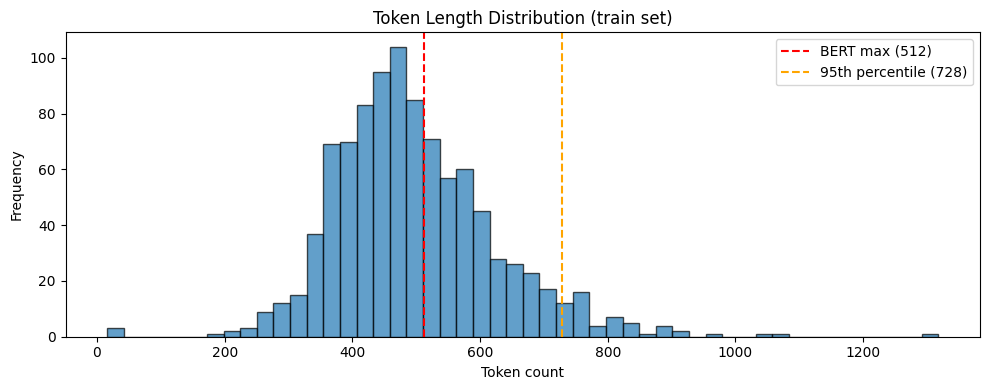

In [7]:
# Analyze token length distribution to choose max_length
import matplotlib.pyplot as plt

token_lengths = train_df['conversation'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

print(f"Token length stats:")
print(f"  Mean:   {token_lengths.mean():.0f}")
print(f"  Median: {token_lengths.median():.0f}")
print(f"  95th %%: {token_lengths.quantile(0.95):.0f}")
print(f"  99th %%: {token_lengths.quantile(0.99):.0f}")
print(f"  Max:    {token_lengths.max():.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(512, color='r', linestyle='--', label='BERT max (512)')
ax.axvline(token_lengths.quantile(0.95), color='orange', linestyle='--', label=f'95th percentile ({token_lengths.quantile(0.95):.0f})')
ax.set_xlabel('Token count')
ax.set_ylabel('Frequency')
ax.set_title('Token Length Distribution (train set)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Set max_length based on the distribution analysis above
# BERT has a max of 512 tokens — adjust if needed based on the histogram
MAX_LENGTH = 512

def tokenize_texts(texts, max_length=MAX_LENGTH):
    """Tokenize a list of texts using the transformer tokenizer."""
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_encodings = tokenize_texts(train_split['conversation'])
val_encodings = tokenize_texts(val_split['conversation'])
test_encodings = tokenize_texts(test_df['conversation'])

print(f"Train encodings - input_ids shape: {train_encodings['input_ids'].shape}")
print(f"Val encodings   - input_ids shape: {val_encodings['input_ids'].shape}")
print(f"Test encodings  - input_ids shape: {test_encodings['input_ids'].shape}")

Train encodings - input_ids shape: torch.Size([776, 512])
Val encodings   - input_ids shape: torch.Size([194, 512])
Test encodings  - input_ids shape: torch.Size([30, 512])


## 6. Create PyTorch Datasets

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = SentimentDataset(train_encodings, train_split['label'])
val_dataset = SentimentDataset(val_encodings, val_split['label'])
test_dataset = SentimentDataset(test_encodings, test_df['label'])

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

# Quick sanity check
sample = train_dataset[0]
print(f"\nSample keys: {list(sample.keys())}")
print(f"input_ids shape: {sample['input_ids'].shape}")
print(f"label: {sample['labels']} ({label_map_inv[sample['labels'].item()]})")

Train dataset: 776 samples
Val dataset:   194 samples
Test dataset:  30 samples

Sample keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids shape: torch.Size([512])
label: 0 (negative)


## 7. Save Preprocessed Data

Save the processed splits and tokenizer config for reproducibility.

In [10]:
output_dir = '../dataset/processed'
os.makedirs(output_dir, exist_ok=True)

# Save cleaned CSVs
train_split.to_csv(f'{output_dir}/train_split.csv', index=False)
val_split.to_csv(f'{output_dir}/val_split.csv', index=False)
test_df.to_csv(f'{output_dir}/test_processed.csv', index=False)

# Save tokenized tensors
torch.save({
    'train_encodings': train_encodings,
    'train_labels': torch.tensor(train_split['label'].values, dtype=torch.long),
    'val_encodings': val_encodings,
    'val_labels': torch.tensor(val_split['label'].values, dtype=torch.long),
    'test_encodings': test_encodings,
    'test_labels': torch.tensor(test_df['label'].values, dtype=torch.long),
    'label_map': label_map,
    'max_length': MAX_LENGTH,
    'model_name': MODEL_NAME
}, f'{output_dir}/tokenized_data.pt')

print(f"Saved to {output_dir}/")
for f in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{f}') / 1024
    print(f"  {f}: {size:.1f} KB")

Saved to ../dataset/processed/
  train_split.csv: 1694.9 KB
  val_split.csv: 435.7 KB
  tokenized_data.pt: 33711.7 KB
  test_processed.csv: 67.4 KB


## Summary

| Step | Action | Justification |
|------|--------|---------------|
| Feature selection | Dropped `issue_category_sub_category`, `agent_experience_level_desc` | Redundant (derived from other columns) |
| Text cleaning | Normalized whitespace only | Transformers handle punctuation/casing natively |
| Label encoding | negative=0, neutral=1, positive=2 | Standard ordinal mapping |
| Train/Val split | 80/20 stratified split from train.csv | Preserves class distribution, no test leakage |
| Tokenization | BERT tokenizer, max_length=512, truncation+padding | BERT's max is 512; median token count is 481, but ~50% of conversations exceed 512 tokens and get truncated — this is a known trade-off |
| Output | Cleaned CSVs + tokenized PyTorch tensors | Reproducible pipeline |

**Note on truncation:** With a mean of ~498 and 95th percentile of ~728 tokens, a significant portion of conversations lose information through truncation at 512. Consider using a model that supports longer sequences (e.g., Longformer) or applying a smarter truncation strategy (e.g., keeping the last N tokens instead, or summarizing) if performance is insufficient.